In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import os

# ===========================================
# 1. 基本路径
# ===========================================
input_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
output_dir = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/processed_output_viz"

os.makedirs(output_dir, exist_ok=True)

# ===========================================
# 2. 读取数据
# ===========================================
df = pd.read_csv(input_path)
df = df.dropna(subset=["rank"])
df = df[df["rank"] > 0]

# ===========================================
# 3. 四种变换
# ===========================================

# Log Transform
df["rank_log"] = np.log(df["rank"] + 1)

# Z-score
scaler_z = StandardScaler()
df["rank_zscore"] = scaler_z.fit_transform(df[["rank"]])

# MinMax
scaler_mm = MinMaxScaler()
df["rank_minmax"] = scaler_mm.fit_transform(df[["rank"]])

# ZIPF
df_sorted = df.sort_values("rank")
df_sorted["zipf_idx"] = np.arange(1, len(df_sorted) + 1)

# ===========================================
# ========  A. ECDF (强烈推荐)  =============
# ===========================================
plt.figure(figsize=(7,5))
sns.ecdfplot(df["rank"])
plt.xscale("log")
plt.xlabel("Rank (log scale)")
plt.ylabel("ECDF")
plt.title("ECDF of Rank (Log Scale)")
plt.tight_layout()
plt.savefig(f"{output_dir}/ecdf_rank_logscale.png", dpi=300)
plt.close()

# ===========================================
# ========  B. KDE (密度图)  =================
# ===========================================
plt.figure(figsize=(7,5))
sns.kdeplot(np.log(df["rank"]), fill=True)
plt.xlabel("Log(Rank)")
plt.title("Density of Log(Rank)")
plt.tight_layout()
plt.savefig(f"{output_dir}/kde_log_rank.png", dpi=300)
plt.close()

# ===========================================
# ========  C. Zipf 双对数图  ================
# ===========================================
plt.figure(figsize=(7,5))
plt.loglog(df_sorted["zipf_idx"], df_sorted["rank"], marker='.', linestyle='none')
plt.xlabel("log(rank index)")
plt.ylabel("log(rank)")
plt.title("Zipf Law Check: Rank vs Rank Index")
plt.tight_layout()
plt.savefig(f"{output_dir}/zipf_loglog.png", dpi=300)
plt.close()

# ===========================================
# ========  D. Category Boxplot  ============
# ===========================================
# 只画前 20 个类别 避免太拥挤
top_categories = df["category"].value_counts().head(20).index
df_sub = df[df["category"].isin(top_categories)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_sub, x="rank_log", y="category", orient="h")
plt.xlabel("Log(Rank)")
plt.ylabel("Category")
plt.title("Category Distribution (Log Rank) – Top 20 Categories")
plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_category_logrank.png", dpi=300)
plt.close()

# ===========================================
# ========  E. MinMax Rank 曲线（检测趋势）===
# ===========================================
sampled = df.sort_values("date").groupby("title").head(1).sample(800)

plt.figure(figsize=(8,5))
sns.kdeplot(sampled["rank_minmax"], fill=True)
plt.xlabel("MinMax Scaled Rank")
plt.title("Density of MinMax Scaled Rank")
plt.tight_layout()
plt.savefig(f"{output_dir}/kde_minmax_rank.png", dpi=300)
plt.close()

# ===========================================
# 保存新的 CSV
# ===========================================
df.to_csv(f"{output_dir}/amazon_rankings_transformed_v2.csv", index=False)

print("===================================================")
print("All visualizations completed!")
print(f"Files saved in: {output_dir}")
print("Generated plots:")
print(" - ecdf_rank_logscale.png")
print(" - kde_log_rank.png")
print(" - zipf_loglog.png")
print(" - boxplot_category_logrank.png")
print(" - kde_minmax_rank.png")
print(" - amazon_rankings_transformed_v2.csv")
print("===================================================")


All visualizations completed!
Files saved in: /blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/processed_output_viz
Generated plots:
 - ecdf_rank_logscale.png
 - kde_log_rank.png
 - zipf_loglog.png
 - boxplot_category_logrank.png
 - kde_minmax_rank.png
 - amazon_rankings_transformed_v2.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IN_CSV = "/blue/qmb6938/_Epoca/Amazon_Rankings/processed_output/amazon_rankings_processed.csv"
OUT_DIR = Path("/blue/qmb6938/_Epoca/Amazon_Rankings/processed_output/trend_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW = 12  # 最近 12 个时间点为例（可改）

df = pd.read_csv(IN_CSV, parse_dates=["date"])
# 必要列检查
for c in ("category","date","rank","rank_log"):
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

# 按 category/date 聚合（以 leader = min rank 代表该类当日表现）
agg = df.groupby(["category","date"]).agg(
    leader_rank=("rank","min"),
    leader_log=("rank_log","min")  # 若没有 rank_log 可用 np.log1p(leader_rank)
).reset_index().sort_values(["category","date"])

# 为每个 category 计算最近 WINDOW 时间段的斜率、波动、top_quartile_weeks 与 gap_slope
def cat_metrics(g):
    g = g.sort_values("date")
    tail = g.tail(WINDOW).reset_index(drop=True)
    n = len(tail)
    if n < 3:
        return pd.Series({
            "slope_log_leader": np.nan, "volatility_z": np.nan,
            "top_quartile_weeks": 0, "gap_slope": np.nan
        })
    t = np.arange(n)
    # slope of log leader (np.polyfit)
    slope = np.polyfit(t, tail["leader_log"].values, 1)[0]
    # volatility of leader_log (std of z-score)
    z = (tail["leader_log"] - tail["leader_log"].mean()) / (tail["leader_log"].std() + 1e-9)
    vol = z.std()
    # compute per-date percentile among categories to count top-quartile weeks
    # (we'll compute daily percentiles separately below)
    return pd.Series({"slope_log_leader": slope, "volatility_z": vol, "top_quartile_weeks": np.nan, "gap_slope": np.nan})

metrics = agg.groupby("category").apply(cat_metrics).reset_index()

# 计算每日全体 leader 的分位，用于 top_quartile_weeks
daily = agg.groupby("date")[["category","leader_rank"]].apply(lambda x: x.assign(pct = x["leader_rank"].rank(pct=True))).reset_index(drop=True)
# merge pct back
agg = agg.merge(daily[["date","category","pct"]], on=["date","category"], how="left")

# 重新计算 top_quartile_weeks and gap_slope for each category
def cat_tail_more(g):
    g = g.sort_values("date")
    tail = g.tail(WINDOW).reset_index(drop=True)
    n = len(tail)
    if n < 3:
        return pd.Series({"top_quartile_weeks": 0, "gap_slope": np.nan})
    tq = int((tail["pct"] <= 0.25).sum())  # 前25%
    # gap to global leader each date
    global_leader = tail["leader_rank"].min()
    gaps = tail["leader_rank"] - global_leader
    gap_slope = np.polyfit(np.arange(n), gaps.values, 1)[0]
    return pd.Series({"top_quartile_weeks": tq, "gap_slope": gap_slope})

more = agg.groupby("category").apply(cat_tail_more).reset_index()
metrics = metrics.merge(more, on="category", how="left")

# 选取候选：slope < 0 （rank在变小，即名次变好），volatility 低，top_quartile_weeks 高
vol_med = metrics["volatility_z"].median()
metrics["score"] = (-metrics["slope_log_leader"]) + (vol_med - metrics["volatility_z"]) * 0.2 + metrics["top_quartile_weeks"] * 0.1
candidates = metrics[(metrics["slope_log_leader"] < 0)].copy()
top3 = candidates.sort_values("score", ascending=False).head(3)

top3.to_csv(OUT_DIR/"top3_categories.csv", index=False)
metrics.to_csv(OUT_DIR/"category_trend_metrics.csv", index=False)
print("Saved metrics and top3 to", OUT_DIR)

# 画图：每个 top category leader_log 时间序列
for cat in top3["category"].tolist():
    ts = agg[agg["category"]==cat].sort_values("date")
    plt.figure(figsize=(8,3.5))
    plt.plot(ts["date"], ts["leader_log"], marker="o")
    plt.title(f"Leader log-rank over time — {cat}")
    plt.xlabel("date"); plt.ylabel("log(rank+1)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR/f"trend_{cat.replace('/','-')}.png", dpi=200)
    plt.close()

KeyError: "['date'] not in index"

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# === 1. 读取文件 ===
input_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
df = pd.read_csv(input_path)

print("✅ 文件读取成功，列名如下:")
print(df.columns.tolist())

# 确保 Rank 存在
if "Rank" not in df.columns:
    raise KeyError("❌ 数据中没有 Rank 列！请检查列名")

# === 2. 生成 Zipf’s Law 变量 ===
# Zipf's Law 对排名建模通常用 1/rank 或 frequency vs rank 的 log–log 拟合
df["zipf_rank"] = 1 / df["Rank"].replace(0, np.nan)

# === 3. 生成 Log Transform 变量 ===
df["log_rank"] = np.log(df["Rank"] + 1)

# === 4. 生成 Z-Score 标准化变量 ===
scaler = StandardScaler()
df["zscore_rank"] = scaler.fit_transform(df[["Rank"]])

# === 5. 生成 0-1 MinMax 归一化变量 ===
mm = MinMaxScaler()
df["minmax_rank"] = mm.fit_transform(df[["Rank"]])

# === 6. 输出特征增强后的 CSV ===
output_file = "amazon_rankings_enhanced_4vars.csv"
df.to_csv(output_file, index=False)
print(f"\n📁✅ 4 种 ranking 变量已生成，并输出到: {output_file}")

# preview 看看
print(df[["Rank","zipf_rank","log_rank","zscore_rank","minmax_rank"]].head())

# === 7. 可视化部分（更适合建模的图） ===

# ① KDE（分布曲线）对比，不指定颜色
plt.figure()
df["Rank"].plot.kde()
plt.title("KDE – Original Rank")
plt.savefig("kde_original_rank.png")

plt.figure()
df["log_rank"].plot.kde()
plt.title("KDE – Log Rank")
plt.savefig("kde_log_rank.png")

plt.figure()
df["zscore_rank"].plot.kde()
plt.title("KDE – Z-Score Rank")
plt.savefig("kde_zscore_rank.png")

plt.figure()
df["minmax_rank"].plot.kde()
plt.title("KDE – MinMax Rank")
plt.savefig("kde_minmax_rank.png")

# ② log-log scatter 体现 Zipf 形状
plt.figure()
plt.scatter(np.log(df["Rank"]), np.log(df["zipf_rank"]))
plt.title("Log-Log Scatter (Zipf Shape View)")
plt.xlabel("log(Rank)")
plt.ylabel("log(1/Rank)")
plt.savefig("scatter_zipf_loglog.png")

print("\n📊✅ 4 张图已生成 ✅")
print("kde_original_rank.png, kde_log_rank.png, kde_zscore_rank.png, kde_minmax_rank.png, scatter_zipf_loglog.png")


✅ 文件读取成功，列名如下:
['item_id', 'rank', 'category', 'date', 'title', 'source_file']


KeyError: '❌ 数据中没有 Rank 列！请检查列名'

✅ 读取成功，列名已清洗:
['item_id', 'rank', 'category', 'date', 'title', 'source_file']

📁✅ 处理完成，已保存为: amazon_rankings_enhanced_4vars.csv
   rank  zipf_rank  log_rank  zscore_rank  minmax_rank
0    70   0.014286  4.262680     0.765313     0.696970
1    44   0.022727  3.806662    -0.138272     0.434343
2    65   0.015385  4.189655     0.591547     0.646465
3    64   0.015625  4.174387     0.556794     0.636364
4    74   0.013514  4.317488     0.904326     0.737374

📊✅ 可视化已生成:
kde_original.png, kde_log.png, kde_zscore.png, kde_minmax.png, scatter_zipf.png


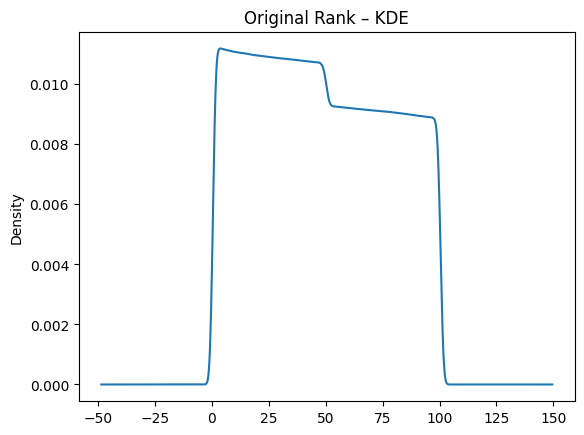

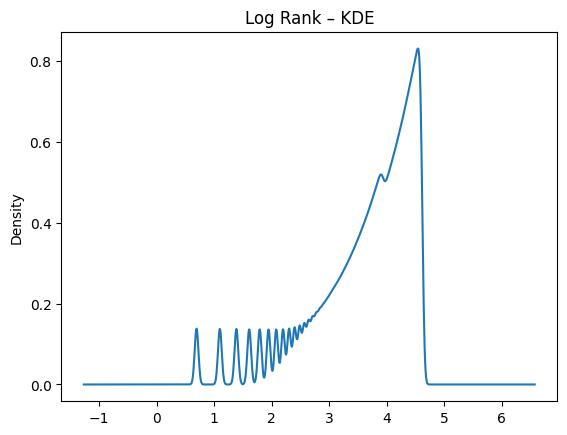

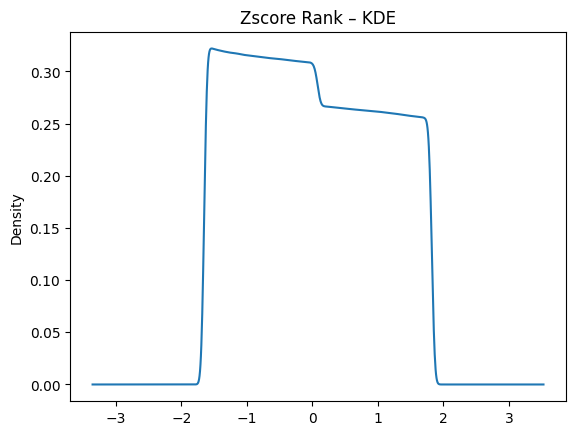

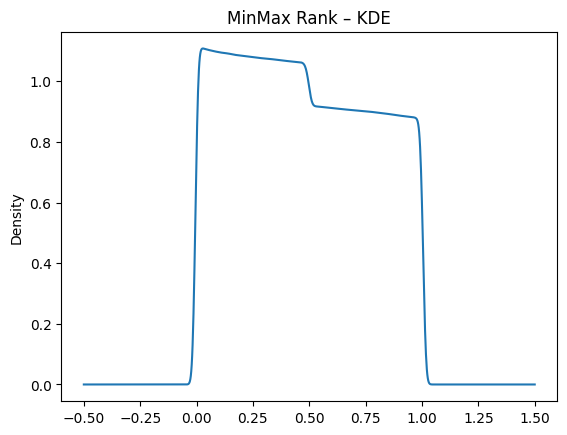

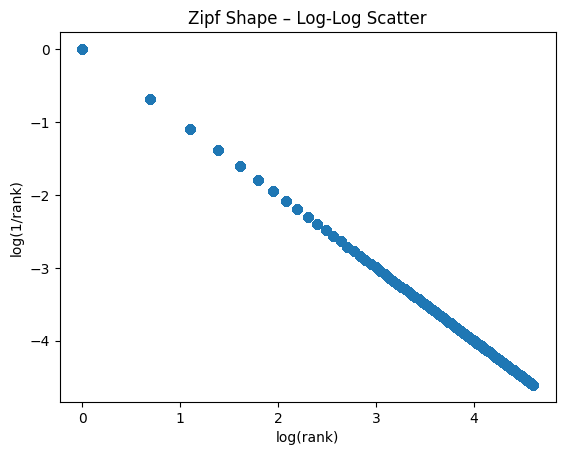

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# === 1. 读取文件 ===
input_path = "/blue/qmb6938/_Epoca/Amazon_Rankings/cleaned_auto/amazon_rankings_merged_auto.csv"
df = pd.read_csv(input_path)

# 统一列名格式（去空格 + 转小写，避免 KeyError）
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

print("✅ 读取成功，列名已清洗:")
print(df.columns.tolist())

# 现在确保 rank 这个字段存在
if "rank" not in df.columns:
    raise KeyError("❌ 数据中没有 rank 列！请检查列名是否不同")

# === 2. 生成 Zipf 变量 (1/rank) ===
df["zipf_rank"] = 1 / df["rank"].replace(0, np.nan)

# === 3. 生成 Log Transform 变量 ===
df["log_rank"] = np.log(df["rank"] + 1)

# === 4. 生成 Z-Score 标准化 ===
scaler = StandardScaler()
df["zscore_rank"] = scaler.fit_transform(df[["rank"]])

# === 5. 生成 0-1 MinMax 归一化 ===
mm = MinMaxScaler()
df["minmax_rank"] = mm.fit_transform(df[["rank"]])

# === 6. 输出增强文件 ===
df.to_csv("amazon_rankings_enhanced_4vars.csv", index=False)
print("\n📁✅ 处理完成，已保存为: amazon_rankings_enhanced_4vars.csv")

print(df[["rank","zipf_rank","log_rank","zscore_rank","minmax_rank"]].head())

# === 7. 可视化部分（更适合建模趋势分析的图） ===

# KDE 分布曲线对比
plt.figure()
df["rank"].plot.kde()
plt.title("Original Rank – KDE")
plt.savefig("kde_original.png")

plt.figure()
df["log_rank"].plot.kde()
plt.title("Log Rank – KDE")
plt.savefig("kde_log.png")

plt.figure()
df["zscore_rank"].plot.kde()
plt.title("Zscore Rank – KDE")
plt.savefig("kde_zscore.png")

plt.figure()
df["minmax_rank"].plot.kde()
plt.title("MinMax Rank – KDE")
plt.savefig("kde_minmax.png")

# Log-Log Scatter 体现 Zipf 形状
plt.figure()
plt.scatter(np.log(df["rank"]), np.log(df["zipf_rank"]))
plt.title("Zipf Shape – Log-Log Scatter")
plt.xlabel("log(rank)")
plt.ylabel("log(1/rank)")
plt.savefig("scatter_zipf.png")

print("\n📊✅ 可视化已生成:")
print("kde_original.png, kde_log.png, kde_zscore.png, kde_minmax.png, scatter_zipf.png")
